## 1. Import Necessary Libraries

In [1]:
!pip install lightgbm

     ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
      --------------------------------------- 0.0/1.5 MB ? eta -:--:--
      --------------------------------------- 0.0/1.5 MB ? eta -:--:--
     - -------------------------------------- 0.1/1.5 MB 787.7 kB/s eta 0:00:02
     --- ------------------------------------ 0.1/1.5 MB 798.9 kB/s eta 0:00:02
     --- ------------------------------------ 0.1/1.5 MB 847.9 kB/s eta 0:00:02
     --- ------------------------------------ 0.1/1.5 MB 847.9 kB/s eta 0:00:02
     --- ------------------------------------ 0.1/1.5 MB 847.9 kB/s eta 0:00:02
     ----- ---------------------------------- 0.2/1.5 MB 588.9 kB/s eta 0:00:03
     ----- ---------------------------------- 0.2/1.5 MB 588.9 kB/s eta 0:00:03
     ----- ---------------------------------- 0.2/1.5 MB 588.9 kB/s eta 0:00:03
     ----- ---------------------------------- 0.2/1.5 MB 588.9 kB/s eta 0:00


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## 2. Import Dataset

In [3]:
credit_card_data = pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3. Data Understanding

### Exploring the variable
* ID : ID of each client

* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

* SEX: Gender (1=male, 2=female)

* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

* MARRIAGE: Marital status (1=married, 2=single, 3=others)

* AGE: Age in years

* PAY_1: Repayment status in September, 2005 (-2 = No consumption, -1 = paid in full, 0 = use of revolving credit (paid minimum only), 1 = payment delay for one month, 2 = payment delay for two months, ... 8 = payment delay for eight months, 9 = payment delay for nine months and above)

* PAY_2: Repayment status in August, 2005 (scale same as above)

* PAY_3: Repayment status in July, 2005 (scale same as above)

* PAY_4: Repayment status in June, 2005 (scale same as above)

* PAY_5: Repayment status in May, 2005 (scale same as above)

* PAY_6: Repayment status in April, 2005 (scale same as above)

* BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

* BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

* BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

* BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

* BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

* BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

* PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

* PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

* PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

* PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

* PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

* PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

#### Target variable
default.payment.next.month: Default payment (1=yes, 0=no)

###### Note: NT is Taiwain Dollars

## 3. Data Understanding

In [4]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [5]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [6]:
credit_card_data.shape

(30000, 25)

## 4. Data Preparation

In [7]:
del credit_card_data["ID"]

In [8]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,male,highschool,married,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,male,university,single,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,male,highschool,married,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [9]:
le = LabelEncoder()
credit_card_data["SEX"] = le.fit_transform(credit_card_data["SEX"])
credit_card_data["EDUCATION"] = le.fit_transform(credit_card_data["EDUCATION"])
credit_card_data["MARRIAGE"] = le.fit_transform(credit_card_data["MARRIAGE"])
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [10]:
credit_card_data.dtypes

LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 5. Model Building

In [11]:
X = credit_card_data.drop("DEFAULT",axis=1)
y = credit_card_data["DEFAULT"]

In [12]:
X.shape,y.shape

((30000, 23), (30000,))

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=123,shuffle=True,stratify=y)

In [14]:
X_train.shape,y_train.shape

((24000, 23), (24000,))

In [15]:
X_test.shape,y_test.shape

((6000, 23), (6000,))

## 6. Model Training

#### Training Time Analysis

In [16]:
adb_classifier  = AdaBoostClassifier()
gb_classifier   = GradientBoostingClassifier(n_estimators=50)
xgb_classifier  = XGBClassifier(n_estimators = 200)
lgbm_classifier = LGBMClassifier(n_estimators = 200)

In [17]:
%%time
adb_classifier.fit(X_train,y_train)

CPU times: total: 1.16 s
Wall time: 1.69 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [18]:
%%time
gb_classifier.fit(X_train,y_train)      #Training Time will increase compared to AgaBoost

CPU times: total: 2 s
Wall time: 4.28 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [20]:
%%time
xgb_classifier.fit(X_train,y_train)     #Training Time will reduce compared to GB

CPU times: total: 2.5 s
Wall time: 376 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [22]:
%%time
lgbm_classifier.fit(X_train,y_train)     #Training Time will reduce even more compared to XGB

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3259
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 531 ms
Wall time: 343 ms


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7. Model Testing

In [23]:
y_pred_adb = adb_classifier.predict(X_test)
y_pred_gb  = gb_classifier.predict(X_test)
y_pred_xgb = xgb_classifier.predict(X_test)
y_pred_lgb = lgbm_classifier.predict(X_test)

## 8. Model Evaluation

### Adaboost Evals 

In [35]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_adb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_adb),4))
print("Recall Score",round(recall_score(y_test,y_pred_adb),4))
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_adb))

Accuracy Score: 0.8218
Precision Score: 0.7048
Recall Score 0.3346
Confusion Matrix
 [[4487  186]
 [ 883  444]]


#### Gradient Boosting

In [34]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_gb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_gb),4))
print("Recall Score",round(recall_score(y_test,y_pred_gb),4))
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_gb))

Accuracy Score: 0.8233
Precision Score: 0.6949
Recall Score 0.3587
Confusion Matrix
 [[4464  209]
 [ 851  476]]


### XGBM 

In [33]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_xgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_xgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_xgb),4))
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score: 0.8085
Precision Score: 0.6196
Recall Score 0.3474
Confusion Matrix
 [[4390  283]
 [ 866  461]]


### LGBM

In [29]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_lgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_lgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_lgb),4))
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_lgb))

Accuracy Score: 0.8228
Precision Score: 0.6902
Recall Score 0.361
Confusion Matrix
 [[4458  215]
 [ 848  479]]


# Let's Learn Feature Impotance

## We are doing this because.....among all features in our dataset only few features are top most important which are taken for predictions by the boosting algorithms....so with that Top features if you are going to predictions,you can reduce the Models's Complexity-(Curse of Dimensionality)

In [38]:
adb_classifier.feature_importances_

array([0.05726899, 0.        , 0.        , 0.01774711, 0.        ,
       0.51398546, 0.03508031, 0.05249326, 0.00468648, 0.01770951,
       0.04232678, 0.01479643, 0.01535836, 0.        , 0.        ,
       0.01846551, 0.        , 0.0878239 , 0.0647271 , 0.03796819,
       0.01956262, 0.        , 0.        ])

In [39]:
adb_feature_imp = adb_classifier.feature_importances_
gb_feature_imp  = gb_classifier.feature_importances_
xgb_feature_imp = xgb_classifier.feature_importances_
lgb_feature_imp = lgbm_classifier.feature_importances_

In [40]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

In [41]:
feature_importance_list = pd.DataFrame(data = { "Features":X.columns,
                                                 "Adaboost_Features":adb_feature_imp,
                                                 "GB_Feature":gb_feature_imp,
                                                 "XGB Features":xgb_feature_imp,
                                                 "LGB_Features":lgb_feature_imp})
feature_importance_list

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
0,LIMIT_BAL,0.057269,0.026852,0.025826,436
1,SEX,0.000000,0.001689,0.020646,82
2,EDUCATION,0.000000,0.002136,0.023102,132
3,MARRIAGE,0.017747,0.002796,0.021784,61
4,AGE,0.000000,0.003232,0.021562,462
5,PAY_1,0.513985,0.655314,0.333799,149
6,PAY_2,0.035080,0.093329,0.097864,74
7,PAY_3,0.052493,0.041462,0.049943,75
8,PAY_4,0.004686,0.016298,0.035714,57
9,PAY_5,0.017710,0.013810,0.038833,56


### Question 1 - Display the Top 10 Features of Adaboost

In [43]:
import seaborn as sns

In [42]:
adaboost_top_features = feature_importance_list.sort_values(by = "Adaboost_Features",ascending = False)
adb_top10_features = adaboost_top_features.head(10)
adb_top10_features

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.333799,149
17,PAY_AMT1,0.087824,0.021428,0.025424,376
18,PAY_AMT2,0.064727,0.018073,0.024516,416
0,LIMIT_BAL,0.057269,0.026852,0.025826,436
7,PAY_3,0.052493,0.041462,0.049943,75
10,PAY_6,0.042327,0.018469,0.041921,74
19,PAY_AMT3,0.037968,0.020043,0.027558,380
6,PAY_2,0.035080,0.093329,0.097864,74
20,PAY_AMT4,0.019563,0.010408,0.024037,342
15,BILL_AMT5,0.018466,0.002390,0.022713,298


<Axes: xlabel='Adaboost_Features', ylabel='Features'>

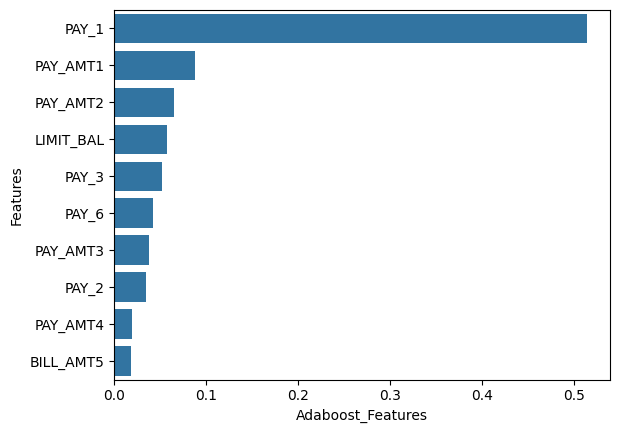

In [45]:
sns.barplot(data = adb_top10_features,x="Adaboost_Features" ,y="Features")

### Question 2 - Display the Top 10 Features of Gradient Boosting

In [46]:
gbboost_top_features = feature_importance_list.sort_values(by = "GB_Feature",ascending = False)
top_10_gb_features = gbboost_top_features.head(10)
top_10_gb_features

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.333799,149
6,PAY_2,0.035080,0.093329,0.097864,74
7,PAY_3,0.052493,0.041462,0.049943,75
0,LIMIT_BAL,0.057269,0.026852,0.025826,436
11,BILL_AMT1,0.014796,0.023012,0.026167,435
17,PAY_AMT1,0.087824,0.021428,0.025424,376
19,PAY_AMT3,0.037968,0.020043,0.027558,380
10,PAY_6,0.042327,0.018469,0.041921,74
18,PAY_AMT2,0.064727,0.018073,0.024516,416
8,PAY_4,0.004686,0.016298,0.035714,57


<Axes: xlabel='GB_Feature', ylabel='Features'>

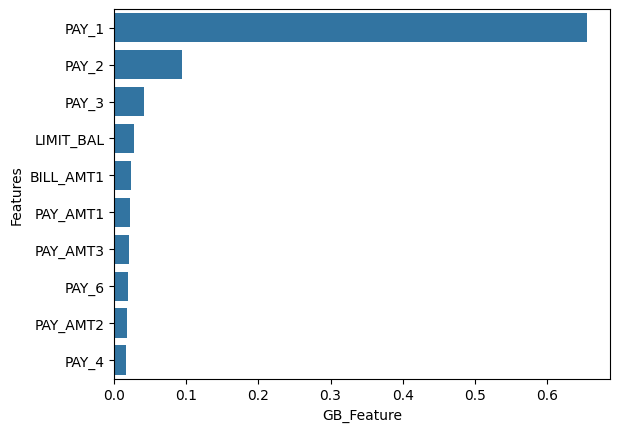

In [47]:
sns.barplot(data=top_10_gb_features,y="Features",x="GB_Feature")

### Question 3 - Display the Top 10 Features of XGBMS

In [48]:
xgbms_top_features = feature_importance_list.sort_values(by = "XGB Features",ascending = False)
xgbms_top10_features = xgbms_top_features.head(10)
xgbms_top10_features

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.333799,149
6,PAY_2,0.035080,0.093329,0.097864,74
7,PAY_3,0.052493,0.041462,0.049943,75
10,PAY_6,0.042327,0.018469,0.041921,74
9,PAY_5,0.017710,0.013810,0.038833,56
8,PAY_4,0.004686,0.016298,0.035714,57
19,PAY_AMT3,0.037968,0.020043,0.027558,380
11,BILL_AMT1,0.014796,0.023012,0.026167,435
0,LIMIT_BAL,0.057269,0.026852,0.025826,436
17,PAY_AMT1,0.087824,0.021428,0.025424,376


<Axes: xlabel='XGB Features', ylabel='Features'>

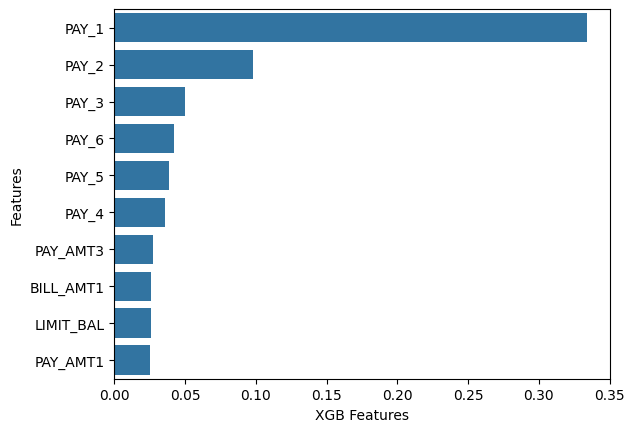

In [50]:
sns.barplot(data= xgbms_top10_features, x = "XGB Features", y = "Features")

### Question 4 - Display the Top 10 Features of LGBMS

In [51]:
lgbms_top_features = feature_importance_list.sort_values(by = "LGB_Features",ascending = False)
lgbms_top10_features = lgbms_top_features.head(10)
lgbms_top10_features

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
22,PAY_AMT6,0.000000,0.008694,0.023499,475
4,AGE,0.000000,0.003232,0.021562,462
0,LIMIT_BAL,0.057269,0.026852,0.025826,436
11,BILL_AMT1,0.014796,0.023012,0.026167,435
18,PAY_AMT2,0.064727,0.018073,0.024516,416
19,PAY_AMT3,0.037968,0.020043,0.027558,380
17,PAY_AMT1,0.087824,0.021428,0.025424,376
21,PAY_AMT5,0.000000,0.004895,0.022903,346
20,PAY_AMT4,0.019563,0.010408,0.024037,342
16,BILL_AMT6,0.000000,0.003280,0.022410,331


<Axes: xlabel='LGB_Features', ylabel='Features'>

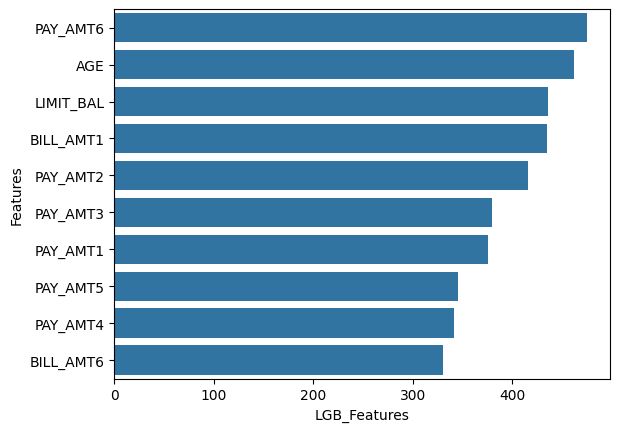

In [52]:
sns.barplot(data= lgbms_top10_features, x = "LGB_Features", y = "Features")

## THE END!!